# 08 · Validação Walk-Forward — seleção de `latent_dim` (M8 · ADR-0010)

**Fase 2, issue #50.** A dimensão do gargalo (`latent_dim`) era uma **decisão de projeto**
(16, compressão ~4:1) ainda não validada por experimento (ADR-0003). Aqui a escolhemos por
**validação cruzada walk-forward** (`TimeSeriesSplit`, ADR-0010): fatias expansíveis do
passado, avaliação no bloco futuro adjacente, repetidas por vários folds — estimativa com
menor variância que um holdout único.

**Anti-vazamento (crítico):** o `MinMaxScaler` é reajustado **dentro de cada fold** (só no
treino daquele fold) e as janelas são geradas dentro de cada recorte — garantido por
`src.validation.walk_forward_splits`. A seleção roda sobre o período de **treino**
(normalidade 2010–2019); o teste (2020+) não participa.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
from src import data, preprocessing as pp
from src.validation import cross_validate_latent_dim
from src.viz import save_fig

set_seeds()
TICKERS = CONFIG['tickers']
N_SPLITS = CONFIG['validation']['n_splits']
CANDIDATES = [8, 16, 32]   # latent_dim a comparar (atual = 16)
EPOCHS_CV = 25             # teto por fold no CV (EarlyStopping governa)

# Série de log-retornos do TREINO (normalidade) por ativo.
train_series = {}
for t in TICKERS:
    r = pp.log_returns(data.load_ticker(t))
    r_train, _ = pp.temporal_split(r)
    train_series[t] = r_train
print('treino (n retornos):', {t: len(s) for t, s in train_series.items()})
print('n_splits:', N_SPLITS, '| candidatos:', CANDIDATES)

treino (n retornos): {'PETR4.SA': 2479, 'VALE3.SA': 2479, 'AMER3.SA': 2479, 'ITUB4.SA': 2479}
n_splits: 10 | candidatos: [8, 16, 32]


## 1. Validação cruzada por ativo

Para cada ativo, `cross_validate_latent_dim` treina o autoencoder em cada fold walk-forward e
coleta o melhor `val_loss` (via EarlyStopping). Retorna média ± desvio por candidato.

In [2]:
cv = {}
for t in TICKERS:
    cv[t] = cross_validate_latent_dim(
        train_series[t], candidates=CANDIDATES, n_splits=N_SPLITS, epochs=EPOCHS_CV
    )
    cv[t]['ticker'] = t
    print(f'--- {t} ---')
    print(cv[t][['val_loss_mean', 'val_loss_std', 'n_folds']].round(6))

cv_all = pd.concat(cv.values())

--- PETR4.SA ---
            val_loss_mean  val_loss_std  n_folds
latent_dim                                      
8                0.016014      0.011320       10
16               0.016002      0.011283       10
32               0.016113      0.011217       10


--- VALE3.SA ---
            val_loss_mean  val_loss_std  n_folds
latent_dim                                      
8                0.017839      0.015540       10
16               0.017813      0.015460       10
32               0.017982      0.015411       10


--- AMER3.SA ---
            val_loss_mean  val_loss_std  n_folds
latent_dim                                      
8                0.016626      0.016884       10
16               0.016562      0.016701       10
32               0.016556      0.016647       10


--- ITUB4.SA ---
            val_loss_mean  val_loss_std  n_folds
latent_dim                                      
8                0.011223      0.008720       10
16               0.011218      0.008597       10
32               0.011149      0.008519       10


## 2. Agregação entre ativos e escolha de `latent_dim`

In [3]:
# latent_dim e um hiperparametro GLOBAL (config.yaml): media o val_loss entre ativos.
agg = cv_all.groupby('latent_dim')['val_loss_mean'].agg(['mean', 'std'])
agg.columns = ['val_loss_mean_4ativos', 'val_loss_std_entre_ativos']
best = agg['val_loss_mean_4ativos'].idxmin()
print('Media do val_loss (4 ativos) por latent_dim:')
print(agg.round(6))
print(f'\nMelhor latent_dim (menor val_loss medio): {best}')

Media do val_loss (4 ativos) por latent_dim:
            val_loss_mean_4ativos  val_loss_std_entre_ativos
latent_dim                                                  
8                        0.015426                   0.002902
16                       0.015399                   0.002888
32                       0.015450                   0.002976

Melhor latent_dim (menor val_loss medio): 16


## 3. Visualização

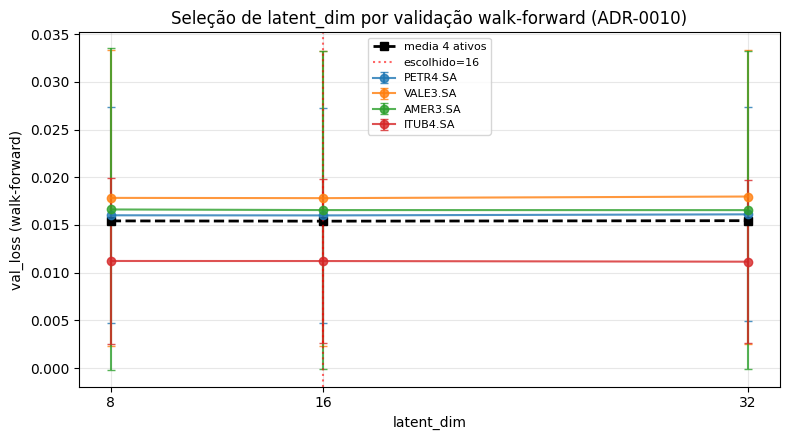

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for t in TICKERS:
    d = cv[t]
    ax.errorbar(d.index, d['val_loss_mean'], yerr=d['val_loss_std'],
                marker='o', capsize=3, label=t, alpha=0.8)
ax.plot(agg.index, agg['val_loss_mean_4ativos'], 'k--s', lw=2, label='media 4 ativos')
ax.axvline(best, color='red', ls=':', alpha=0.6, label=f'escolhido={best}')
ax.set_xlabel('latent_dim'); ax.set_ylabel('val_loss (walk-forward)')
ax.set_xticks(CANDIDATES)
ax.set_title('Seleção de latent_dim por validação walk-forward (ADR-0010)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()
save_fig(fig, 'm8_walkforward_latent')
plt.show()

## Conclusões

- A validação **walk-forward** dá uma estimativa de `val_loss` por `latent_dim` com variância
  entre folds — base mais honesta que o holdout único para a escolha (ADR-0010).
- O scaler foi reajustado **por fold** e as janelas geradas dentro de cada recorte: a seleção
  não vê o futuro (ADR-0001 preservado por fold).
- O `latent_dim` escolhido (Seção 2) atualiza/confirma o ADR-0003 e o `config.yaml`.
- Próximo (M8): transição multivariada OHLCV (`preprocess_ticker_multivariate`, ADR-0011) para
  habilitar anomalias de volume, validada com esta mesma malha walk-forward.